In [ ]:
# Install packages.
!pip install swig mediapy
!pip install mujoco==3.1.4
!pip install minari==0.5.3
!pip install gymnasium_robotics==1.2.4
!pip install torch
!pip install torchrl==0.7.0
!pip install gymnasium==0.28.1

# Imports and Functions

In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import minari
from tqdm import tqdm
from collections import defaultdict

# Change to glfw whenon Mac. This might fuck up the lighting.
%env MUJOCO_GL=egl
import mediapy as media

env: MUJOCO_GL=egl


In [ ]:
def render_episode(policy, env, timeout=1000):
	frames = []
	score = 0
	t = 0
	state = env.reset()[0]
	terminated = truncated = False
	while not terminated and not truncated and not t >= timeout:
		frame = env.render()
		frames.append(frame)
		action = policy(state)
		state, reward, terminated, truncated, _ = env.step(action)
		score += reward
		t += 1
	env.close()
	print(f"Finished episode. Cummulative Return: {score}")
	media.show_video(frames, fps=50, loop=True)

In [ ]:
class MinariReplayBuffer:
	def __init__(self, dataset, batch_size, normalize_rewards=False,
			  device="cuda" if torch.cuda.is_available() else "cpu", dtype=torch.float32):
		self.batch_size = batch_size
		self.device = device
		self.data = defaultdict(list)
		for episode in dataset:
			self.data['observations'].append(torch.tensor(episode.observations[:-1], device=device, dtype=dtype))
			self.data['actions'].append(torch.tensor(episode.actions, device=device, dtype=dtype))
			self.data['rewards'].append(torch.tensor(episode.rewards, device=device, dtype=dtype))
			self.data['next_observations'].append(torch.tensor(episode.observations[1:], device=device, dtype=dtype))
			self.data['dones'].append(torch.tensor(episode.terminations|episode.truncations, device=device, dtype=dtype))
		# Concatenate all data into single tensors
		for key in self.data.keys():
			self.data[key] = torch.cat(self.data[key], dim=0)

		# Normalize rewards if specified
		if normalize_rewards:
			self.data['rewards'] = (self.data['rewards'] - self.data['rewards'].mean()) / (self.data['rewards'].std() + 1e-8)

	def __len__(self):
		return len(self.data['observations']) // self.batch_size

	def __iter__(self):
		indices = torch.randperm(len(self.data['observations']))
		for i in range(0, len(indices), self.batch_size):
			batch_indices = indices[i:i+self.batch_size]
			yield {key: self.data[key][batch_indices] for key in self.data.keys()}

# Imitation Learning
Imitation learning is a machine learning approach where an agent learns to perform a task by imitating the behavior of an expert. In imitation learning, the agent learns from a dataset of expert demonstrations, where each demonstration consists of a sequence of states and the corresponding actions taken by the expert. The goal of imitation learning is to learn a policy that can mimic the expert's behavior and perform the task accurately.

There are several types of imitation learning algorithms, each with its own approach and characteristics. One common type is behavior cloning, where the agent learns to directly mimic the expert's actions based on the observed states. Another type is inverse reinforcement learning, which aims to infer the underlying reward function from the expert's behavior and then optimize the agent's policy based on this inferred reward function. Additionally, there are also approaches like generative adversarial imitation learning, where the agent learns to generate actions that are indistinguishable from the expert's actions through a competitive training process.

The main difference between imitation learning and reinforcement learning lies in the source of knowledge. In imitation learning, the agent learns directly from the expert's behavior, leveraging the expert's knowledge and expertise. In contrast, reinforcement learning learns through trial and error, exploring the environment and learning from the feedback it receives.
In terms of implementation, imitation learning requires a dataset of expert demonstrations, which can be costly and time-consuming to collect. However, it can achieve good performance quickly, as it learns from the expert's behavior. On the other hand, reinforcement learning starts from scratch and learns through interaction with the environment, which can be time-consuming and require a large number of interactions to achieve good performance.


## Datasets for Robot Learning
Datasets play a crucial role in robot learning, providing valuable training data for developing and improving robotic systems. These datasets consist of expert demonstrations, where human operators perform tasks and their actions are recorded along with corresponding states. The datasets capture the knowledge and expertise of the experts, allowing robots to learn from their behavior. By training on these datasets, robots can acquire the necessary skills and knowledge to perform complex tasks autonomously. These datasets are often collected through extensive human demonstrations or simulations, ensuring a diverse range of scenarios and environments. They serve as a valuable resource for researchers and developers, enabling them to train and evaluate robot learning algorithms, refine robot behaviors, and advance the field of robotics.

In [ ]:
dataset_name = 'D4RL/pen/expert-v2'
# Load the dataset and render an episode using random actions
dataset = minari.load_dataset(dataset_name, download=True)
render_env = dataset.recover_environment(render_mode="rgb_array")
render_episode(lambda x: render_env.action_space.sample(), render_env)

Finished episode. Cummulative Return: -639.8971970797503


This browser does not support the video tag.


In [ ]:
# Observation and action space of our environment
# Note that this is a very high-dimensional problem that a reinforcement learning agent would need many interactions to solve
print("Action Space:", dataset.action_space)
print("Observation Space:", dataset.observation_space)
print("Number of episodes:", len(dataset))

Action Space: Box(-1.0, 1.0, (24,), float32)
Observation Space: Box(-inf, inf, (45,), float64)
Number of episodes: 4958


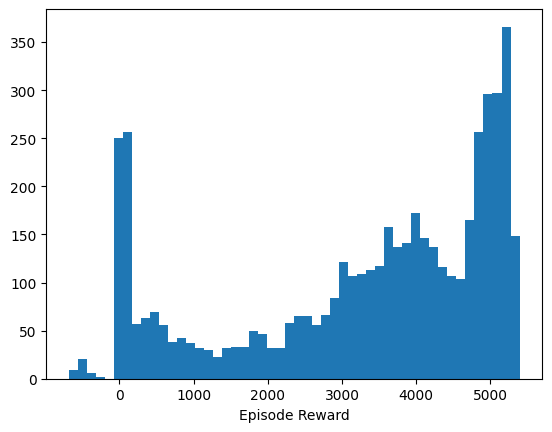

In [ ]:
# Plot distribution of episode returns.
episode_rewards = [episode.rewards.sum() for episode in dataset]
plt.hist(episode_rewards, bins=50)
plt.xlabel("Episode Reward")
plt.show()

## Behavior Cloning
Behavior cloning is a machine learning approach where an agent learns to perform a task by imitating the behavior of an expert. In behavior cloning, the agent learns directly from a dataset of expert demonstrations, where each demonstration consists of a sequence of states and the corresponding actions taken by the expert. The goal of behavior cloning is to learn a policy that can mimic the expert's behavior and accurately perform the task. This approach can be implemented using a neural network model, where the input is the state and the output is the predicted action. By training the model on the expert demonstrations, the agent can learn to make decisions similar to the expert and achieve good performance.

In [ ]:
class BehaviorCloningAgent:
	def __init__(self, dataset_name, device="cuda" if torch.cuda.is_available() else "cpu"):
		self.device = device
		self.dataset = minari.load_dataset(dataset_name, download=False)
		self.replay_buffer = MinariReplayBuffer(
			dataset=dataset,
			batch_size=128,)
		self.model = nn.Sequential(
			nn.Linear(self.dataset.observation_space.shape[0], 64),
			nn.ReLU(),
			nn.Linear(64, 64),
			nn.ReLU(),
			nn.Linear(64, self.dataset.action_space.shape[0]),
			nn.Tanh()
		).to(device)
		self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
		self.loss = nn.MSELoss()


	def train(self, num_epochs=10):
		for epoch in range(num_epochs):
			running_loss = 0.0
			with tqdm(total=len(self.replay_buffer), desc=f"Epoch {epoch+1}/{num_epochs}", leave=True) as pbar:
				for batch in self.replay_buffer:
					observations, target_actions = batch['observations'], batch['actions']
					actions = self.model(observations)
					loss = self.loss(actions, target_actions)
					self.optimizer.zero_grad()
					loss.backward()
					self.optimizer.step()
					running_loss += loss.item()
					pbar.update(1)
					pbar.set_postfix(loss=running_loss / (pbar.n + 1))

	def act(self, state):
		with torch.no_grad():
			return self.model(torch.from_numpy(state).to(self.device).to(torch.float32)).cpu().numpy()

In [ ]:
# Train the agent
agent = BehaviorCloningAgent(dataset_name)
agent.train(num_epochs=10)

Epoch 1/10: 3901it [00:04, 922.39it/s, loss=0.103]                           
Epoch 2/10: 3901it [00:04, 906.65it/s, loss=0.0973]                          
Epoch 3/10: 3901it [00:04, 896.59it/s, loss=0.0968]                          
Epoch 4/10: 3901it [00:04, 891.42it/s, loss=0.0965]                          
Epoch 5/10: 3901it [00:04, 898.89it/s, loss=0.0963]                          
Epoch 6/10: 3901it [00:04, 933.24it/s, loss=0.0962]                          
Epoch 7/10: 3901it [00:04, 918.55it/s, loss=0.096]                           
Epoch 8/10: 3901it [00:04, 905.55it/s, loss=0.096]                           
Epoch 9/10: 3901it [00:04, 891.41it/s, loss=0.0959]                          
Epoch 10/10: 3901it [00:04, 884.64it/s, loss=0.0958]                          


In [ ]:
# render an episode using the trained BC agent
render_env = dataset.recover_environment(render_mode="rgb_array")
render_episode(agent.act, render_env)


Finished episode. Cummulative Return: 10151.095551903236


This browser does not support the video tag.


### Tasks:
1. This converged very quickly to a very good solution. However, we have to trust that all the data we are feeding our algorithm is reasonable. If we have a mixed dataset of good and not-so-good decisions, the resulting agent copies the behaviors from this dataset and therefore may not perform as well. Replace 'pen-expert-v2' by 'pen-cloned-v2' and retrain the model to see what happens for a mixed dataset of good and bad examples.
2. We trained a neural network to minimize the MSE between the action it outputs and the action in the dataset. Why is this particularly bad in case of data from different skill levels? What could be a better approach for BC?
3. The performance of BC for the mixed dataset was likely not very good. But why are we not simply using the off-policy algorithms that we learned about (e.g., DQN and SAC) to do reinforcement learning and just fill our replay buffer with the dataset? Code this. What happens? Why do you think this does not perform well?

**Solution: Behavior Cloning: **
1. For BC to work we have to rely on high quality demonstrations. If demonstrations are sub-optimal the resulting policy will be too.



2. With MSE we minimize the quadratic error of a prediction. This makes sense as long as the data is uni-modal. If the data is multi-modal, the resulting policy may be sub-optimal.



3. Simple off-policy RL algorithms perform poorly on offline datasets because they tend to overestimate the value of actions and states not well represented in the data, due to distributional shift and extrapolation error. Without the ability to interact with the environment, these algorithms cannot correct their mistakes or gather new, informative experiences. As a result, their value estimates become unreliable, often leading to unstable or unsafe learned policies.

# Offline Reinforcement Learning
Offline RL algorithms promise to learn effective policies from previously-collected, static datasets without further interaction. However, in practice, offline RL presents a major challenge, and standard off-policy RL methods can fail due to overestimation of values induced by the distributional shift between the dataset and the learned policy, especially when training on complex and multi-modal data distributions. For example, we can imagine a DQN agent that learns by updating its Q values through an estimate that is based on the maximum over Q values of potential subsequent actions. If we do not have data for these action in our dataset, our value update will likely lead to overestimation of the Q value.

## Batch-Constrained Deep Q-learning
[BCQ](https://arxiv.org/pdf/1812.02900) mitigates these issues by incorporating a generative model to constrain action selection to those likely under the dataset's behavior policy (using a VAE). It employs a variant of the Q-learning algorithm, adjusted to work with a fixed dataset, and introduces a thresholding mechanism to filter actions based on their estimated Q-values. This approach reduces the risk of extrapolation errors in value estimation. The implementation involves training two networks: a generative model to propose actions and a modified Q-network to evaluate these actions, ensuring they are within the distribution of the dataset.

In [ ]:
# Actor model (smaller, using Sequential API)
class Actor(nn.Module):
	def __init__(self, state_dim, action_dim, max_action, phi=0.05):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(state_dim + action_dim, 128),
			nn.ReLU(),
			nn.Linear(128, action_dim),
			nn.Tanh()
		)
		self.max_action = max_action
		self.phi = phi

	def forward(self, state, action):
		a = self.net(torch.cat([state, action], dim=1))
		a = self.phi * self.max_action * a
		return (a + action).clamp(-self.max_action, self.max_action)

In [ ]:
# Critic model using Sequential API and smaller architecture
class Critic(nn.Module):
	def __init__(self, state_dim, action_dim):
		super().__init__()
		self.q1_net = nn.Sequential(
			nn.Linear(state_dim + action_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 1)
		)
		self.q2_net = nn.Sequential(
			nn.Linear(state_dim + action_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 1)
		)

	def forward(self, state, action):
		x = torch.cat([state, action], dim=1)
		q1 = self.q1_net(x)
		q2 = self.q2_net(x)
		return q1, q2

	def q1(self, state, action):
		x = torch.cat([state, action], dim=1)
		return self.q1_net(x)


In [ ]:
# Conditional VAE that samples actions that are likely under the data distribution (smaller, Sequential API)
class VAE(nn.Module):
	def __init__(self, state_dim, action_dim, latent_dim, max_action, device):
		super().__init__()
		self.encoder = nn.Sequential(
			nn.Linear(state_dim + action_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU()
		)
		self.mean = nn.Linear(128, latent_dim)
		self.log_std = nn.Linear(128, latent_dim)

		self.decoder = nn.Sequential(
			nn.Linear(state_dim + latent_dim, 128),
			nn.ReLU(),
			nn.Linear(128, 128),
			nn.ReLU(),
			nn.Linear(128, action_dim),
			nn.Tanh()
		)
		self.max_action = max_action
		self.latent_dim = latent_dim
		self.device = device

	def forward(self, state, action):
		x = torch.cat([state, action], dim=1)
		h = self.encoder(x)
		mean = self.mean(h)
		log_std = self.log_std(h).clamp(-4, 15)
		std = torch.exp(log_std)
		z = mean + std * torch.randn_like(std)
		u = self.decode(state, z)
		return u, mean, std

	def decode(self, state, z=None):
		if z is None:
			z = torch.randn((state.shape[0], self.latent_dim), device=self.device).clamp(-0.5, 0.5)
		x = torch.cat([state, z], dim=1)
		a = self.decoder(x)
		return self.max_action * a


In [ ]:
# Batch-Constrained Deep Q-Learning
class BCQAgent():
	def __init__(self, dataset_name, device="cuda" if torch.cuda.is_available() else "cpu", discount=0.99, tau=4e-5, lmbda=0.75, n=10, phi=0.025):
		self.device = device
		self.dataset = minari.load_dataset(dataset_name, download=True)
		self.replay_buffer = MinariReplayBuffer(
			dataset=self.dataset,
			batch_size=128,)
		action_dim = self.dataset.action_space.shape[0]
		observation_dim = self.dataset.observation_space.shape[0]
		max_action = self.dataset.action_space.high[0]
		latent_dim = action_dim

		self.actor = Actor(observation_dim, action_dim, max_action, phi).to(device)
		self.actor_target = copy.deepcopy(self.actor)
		self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=1e-3)

		self.critic = Critic(observation_dim, action_dim).to(device)
		self.critic_target = copy.deepcopy(self.critic)
		self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=1e-3)

		self.vae = VAE(observation_dim, action_dim, latent_dim, max_action, device).to(device)
		self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)

		self.max_action = max_action
		self.action_dim = action_dim
		self.discount = discount
		self.tau = tau # for soft update of target parameters
		self.n = n # number of actions to sample from the VAE
		self.lmbda = lmbda # for the soft-clipped double Q-learning
		self.device = device


	def act(self, state):
		with torch.no_grad():
			# return self.vae.decode(torch.tensor(state).to(self.device, torch.float32).unsqueeze(0)).cpu().numpy()[0]
			state = torch.FloatTensor(state.reshape(1, -1)).repeat(100, 1).to(self.device)
			action = self.actor(state, self.vae.decode(state))
			# return action.cpu().numpy()[0]
			q1 = self.critic.q1(state, action)
			ind = q1.argmax(0)
		return action[ind].cpu().data.numpy().flatten()


	def train(self, num_epochs=10):
		for epoch in range(num_epochs):
			# print(f"Training epoch {epoch+1}/{num_epochs}")
			running_vae_loss = running_critic_loss = running_actor_loss = 0.0
			count = 0
			with tqdm(total=len(self.replay_buffer), desc=f"Epoch {epoch+1}/{num_epochs}", leave=True) as pbar:
				for batch in self.replay_buffer:
					observations = batch['observations']
					actions = batch['actions']
					rewards = batch['rewards'].reshape(-1, 1)  # Ensure rewards are in the correct shape
					next_observations = batch['next_observations']
					dones = batch['dones'].reshape(-1, 1)  # Ensure dones are in the correct shape
					not_dones = 1 - dones

					# Variational Auto-Encoder Training
					recon, mean, std = self.vae(observations, actions)
					recon_loss = F.mse_loss(recon, actions)
					KL_loss	= -0.5 * (1 + torch.log(std.pow(2)) - mean.pow(2) - std.pow(2)).mean()
					vae_loss = recon_loss + 0.5 * KL_loss

					self.vae_optimizer.zero_grad()
					vae_loss.backward()
					self.vae_optimizer.step()
					running_vae_loss += vae_loss.item()

					# Critic Training
					with torch.no_grad():
						# Duplicate next state 10 times so we can maximize over the predicted values.
						next_observations_interleaved = torch.repeat_interleave(next_observations, self.n, dim=0)

						# Compute value of perturbed actions sampled from the VAE (note that we sample the latent of the VAE so the actions are not deterministic)
						target_Q1, target_Q2 = self.critic_target(next_observations_interleaved,
												self.actor_target(next_observations_interleaved, self.vae.decode(next_observations_interleaved)))

						# Soft Clipped Double Q-learning
						target_Q = self.lmbda * torch.min(target_Q1, target_Q2) + (1. - self.lmbda) * torch.max(target_Q1, target_Q2)
						# Take max over each action sampled from the VAE
						target_Q = target_Q.reshape(len(observations), self.n).max(1, keepdim=True)[0]

						target_Q = rewards + not_dones * self.discount * target_Q

					current_Q1, current_Q2 = self.critic(observations, actions)
					critic_loss = F.mse_loss(current_Q1, target_Q) + F.mse_loss(current_Q2, target_Q)

					self.critic_optimizer.zero_grad()
					critic_loss.backward()
					self.critic_optimizer.step()
					running_critic_loss += critic_loss.item()

					# Pertubation Model / Action Training
					sampled_actions = self.vae.decode(observations)
					perturbed_actions = self.actor(observations, sampled_actions)
					# Update through DPG
					actor_loss = -self.critic_target.q1(observations, perturbed_actions).mean()

					self.actor_optimizer.zero_grad()
					actor_loss.backward()
					self.actor_optimizer.step()
					running_actor_loss += actor_loss.item()

					# Update Target Networks
					for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
						target_param.data = self.tau * param.data + (1 - self.tau) * target_param.data

					for param, target_param in zip(self.actor.parameters(), self.actor_target.parameters()):
						target_param.data = self.tau * param.data + (1 - self.tau) * target_param.data

					count += 1
					pbar.update(1)
					pbar.set_postfix(VAE_Loss=running_vae_loss/count, Critic_Loss=running_critic_loss/count, Actor_Loss=running_actor_loss/count)

In [ ]:
# Train the agent
agent = BCQAgent("D4RL/pen/cloned-v2")

In [ ]:
agent.train(num_epochs=10)

Epoch 1/10: 3907it [00:18, 212.58it/s, Actor_Loss=-0.29, Critic_Loss=572, VAE_Loss=0.0346]                                
Epoch 2/10: 3907it [00:18, 212.73it/s, Actor_Loss=-1.29, Critic_Loss=284, VAE_Loss=0.0205]                           
Epoch 3/10: 3907it [00:18, 210.78it/s, Actor_Loss=-3.06, Critic_Loss=215, VAE_Loss=0.0185]                          
Epoch 4/10: 3907it [00:18, 209.83it/s, Actor_Loss=-5.36, Critic_Loss=182, VAE_Loss=0.0173]                          
Epoch 5/10: 3907it [00:18, 207.72it/s, Actor_Loss=-8.01, Critic_Loss=163, VAE_Loss=0.0165]                          
Epoch 6/10: 3907it [00:18, 205.64it/s, Actor_Loss=-10.9, Critic_Loss=152, VAE_Loss=0.0159]                          
Epoch 7/10: 3907it [00:19, 202.28it/s, Actor_Loss=-13.9, Critic_Loss=147, VAE_Loss=0.0154]                          
Epoch 8/10: 3907it [00:18, 211.20it/s, Actor_Loss=-17, Critic_Loss=145, VAE_Loss=0.0151]                            
Epoch 9/10: 3907it [00:19, 201.05it/s, Actor_Loss=-20.2, 

In [ ]:
# render an episode using the trained BCQ agent
render_env = agent.dataset.recover_environment(render_mode="rgb_array")
render_episode(agent.act, render_env)

Finished episode. Cummulative Return: 9420.183975316915


This browser does not support the video tag.


### Tasks:
1. Compare the Critic in BCQ to DQN (from E05).
2. What does the VAE do in BCQ? How does it help to eliminate the overestimation of Q-values of DQN?
3. How is the Actor used in BCQ?
4. Read the paper on [CQL](https://arxiv.org/pdf/2006.04779) and implement it. Compare it to BCQ and DQN.

**Solution: BCQ**
1. The DQN agent predicts a Q-value for every available action for a given state. The BCQ critic takes in an action and a state and predicts Q-values so that we can back propagate through the critic to update the actor parameters.



2. The VAE is trained on the offline dataset to model the distribution of actions taken by the behavior policy, allowing it to generate plausible actions for each state. During decision-making, the agent samples several actions from the VAE and only considers these in-distribution actions (plus small perturbations), which helps prevent the selection of out-of-distribution actions and reduces extrapolation error.



3. The actor in BCQ perturbs actions sampled from the VAE, making small adjustments to improve performance, and the agent selects the perturbed action with the highest Q-value for each state. This ensures the chosen actions remain close to the dataset while allowing for policy improvement.



In [ ]:
## Solution
class CQLCritic(nn.Module):
	def __init__(self, obs_dim, act_dim):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(obs_dim + act_dim, 256),
			nn.ReLU(),
			nn.Linear(256, 256),
			nn.ReLU(),
			nn.Linear(256, 1)
		)
	def forward(self, obs, act):
		return self.net(torch.cat([obs, act], dim=-1))

class CQLActor(nn.Module):
	def __init__(self, obs_dim, act_dim, max_action):
		super().__init__()
		self.net = nn.Sequential(
			nn.Linear(obs_dim, 256),
			nn.ReLU(),
			nn.Linear(256, 256),
			nn.ReLU(),
			nn.Linear(256, act_dim),
			nn.Tanh()
		)
		self.max_action = max_action
	def forward(self, obs):
		return self.max_action * self.net(obs)

class CQLAgent:
	def __init__(self, dataset_name, device="cuda" if torch.cuda.is_available() else "cpu", discount=0.99, tau=4e-5, cql_alpha=1.0, num_random=10):
		self.device = device
		self.dataset = minari.load_dataset(dataset_name, download=True)
		self.replay_buffer = MinariReplayBuffer(
			dataset=self.dataset,
			batch_size=128,)
		action_dim = self.dataset.action_space.shape[0]
		observation_dim = self.dataset.observation_space.shape[0]
		max_action = self.dataset.action_space.high[0]
		self.critic = CQLCritic(observation_dim, action_dim).to(device)
		self.critic_target = CQLCritic(observation_dim, action_dim).to(device)
		self.critic_target.load_state_dict(self.critic.state_dict())
		self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=3e-4)
		self.actor = CQLActor(observation_dim, action_dim, max_action).to(device)
		self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=3e-4)
		self.max_action = max_action
		self.discount = discount
		self.tau = tau
		self.num_random = num_random
		self.cql_alpha = cql_alpha  # CQL regularization strength

	def act(self, state):
		state = torch.FloatTensor(state).to(self.device).unsqueeze(0)
		with torch.no_grad():
			action = self.actor(state)
		return action.cpu().numpy()[0]

	def train(self, num_epochs=10):
		for epoch in range(num_epochs):
			running_critic_loss = running_actor_loss = 0.0
			count = 0
			with tqdm(total=len(self.replay_buffer), desc=f"Epoch {epoch+1}/{num_epochs}", leave=True) as pbar:
				for batch in self.replay_buffer:
					state = batch['observations']
					action = batch['actions']
					reward = batch['rewards'].unsqueeze(1)
					next_state = batch['next_observations']
					done = batch['dones'].unsqueeze(1)

					# Critic loss (standard Bellman error)
					with torch.no_grad():
						next_actions = self.actor(next_state)
						target_Q = self.critic_target(next_state, next_actions)
						target_Q = reward + (1 - done) * self.discount * target_Q
					current_Q = self.critic(state, action)
					bellman_loss = F.mse_loss(current_Q, target_Q)

					# CQL conservative penalty
					# Sample random actions uniformly
					random_actions = torch.FloatTensor(len(state) * self.num_random, action.shape[1]).uniform_(
						-self.max_action, self.max_action).to(self.device)
					obs_repeat = state.unsqueeze(1).repeat(1, self.num_random, 1).view(-1, state.shape[1])
					random_Q = self.critic(obs_repeat, random_actions).view(len(state), self.num_random)

					# Q-values for actions from current policy
					curr_policy_actions = self.actor(obs_repeat)
					curr_policy_Q = self.critic(obs_repeat, curr_policy_actions).view(len(state), self.num_random)

					# Q-values for actions from dataset
					data_Q = self.critic(state, action)

					# Log-sum-exp for conservative objective
					cat_Q = torch.cat([random_Q, curr_policy_Q], dim=1)
					cql_loss = (torch.logsumexp(cat_Q, dim=1) - data_Q.squeeze(1)).mean()

					# Total critic loss
					critic_loss = bellman_loss + self.cql_alpha * cql_loss
					self.critic_optimizer.zero_grad()
					critic_loss.backward()
					self.critic_optimizer.step()
					running_critic_loss += critic_loss.item()

					# Actor update (maximize Q)
					actor_actions = self.actor(state)
					actor_loss = -self.critic(state, actor_actions).mean()
					self.actor_optimizer.zero_grad()
					actor_loss.backward()
					self.actor_optimizer.step()
					running_actor_loss += actor_loss.item()

					# Soft update target
					for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
						target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

					count += 1
					pbar.update(1)
					pbar.set_postfix(Critic_Loss=running_critic_loss/count, Actor_Loss=running_actor_loss/count)

In [ ]:
## Solution
agent = CQLAgent("D4RL/pen/cloned-v2")
agent.train(num_epochs=10)

Epoch 1/10: 3907it [00:15, 253.50it/s, Actor_Loss=-33.4, Critic_Loss=211]                            
Epoch 2/10: 3907it [00:15, 253.89it/s, Actor_Loss=-29.6, Critic_Loss=55.1]                          
Epoch 3/10: 3907it [00:15, 252.47it/s, Actor_Loss=-30.3, Critic_Loss=40.5]                          
Epoch 4/10: 3907it [00:15, 250.89it/s, Actor_Loss=-32.1, Critic_Loss=35]                            
Epoch 5/10: 3907it [00:15, 249.66it/s, Actor_Loss=-34.4, Critic_Loss=32.1]                          
Epoch 6/10: 3907it [00:15, 246.56it/s, Actor_Loss=-37, Critic_Loss=30.7]                            
Epoch 7/10: 3907it [00:15, 244.44it/s, Actor_Loss=-39.6, Critic_Loss=30.2]                          
Epoch 8/10: 3907it [00:16, 240.56it/s, Actor_Loss=-42.1, Critic_Loss=30.3]                          
Epoch 9/10: 3907it [00:16, 237.64it/s, Actor_Loss=-44.9, Critic_Loss=31.2]                          
Epoch 10/10: 3907it [00:16, 234.13it/s, Actor_Loss=-47.8, Critic_Loss=32.4]               

In [ ]:
## Solution
render_env = agent.dataset.recover_environment(render_mode="rgb_array")
render_episode(agent.act, render_env)

Finished episode. Cummulative Return: 10584.10477506963


This browser does not support the video tag.
